In [72]:
import matplotlib.pyplot as plt
import numpy as np
# %%
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

def save_scan(name):
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

#to be rapaired:
def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)

In [73]:
# bleaching
def bleach(n_times = 10):
    for i in range(n_times):
        print(i)
        scanning_probe_logic.toggle_scan(True, ('x', 'y'))
        while scanning_probe_logic.module_state()=='locked':
                time.sleep(1)

In [74]:
scan_data = scanning_data_logic.get_current_scan_data()

In [75]:
source = 'APD2'

data = scan_data.data[source]
(xrange,yrange) = scan_data.scan_range

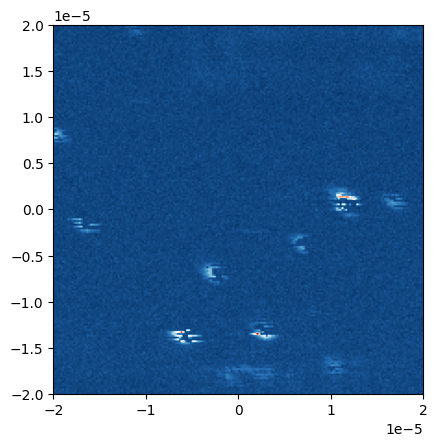

In [76]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

In [77]:
import numpy as np

# ——— USER SETTINGS ———
source = 'APD2'
dx = 4e-6   # grid step in x
dy = 4e-6   # grid step in y

# ——— LOAD YOUR SCAN ———
data = scan_data.data[source]        # assume shape (ny, nx)
(x_min, x_max), (y_min, y_max) = scan_data.scan_range

# ——— BUILD GRID COORDINATES ———
# include the endpoint if it falls exactly on a step
x_coords = np.arange(x_min, x_max + dx/2, dx)
y_coords = np.arange(y_min, y_max + dy/2, dy)

# 2D meshgrid of coordinates, shape = (len(y_coords), len(x_coords))
X_grid, Y_grid = np.meshgrid(x_coords, y_coords)

# ——— FLATTENED POINT LIST ———
# an (N,2) array of (x,y) pairs you can iterate
points_flat = np.column_stack((X_grid.ravel(), Y_grid.ravel()))


# ——— EXAMPLES ———
print("Grid shape:", X_grid.shape)       
print("Flattened points:", points_flat.shape)
print("Flattened values:", values_flat.shape)

# # now you can loop:
# for (x, y), val in zip(points_flat, values_flat):
#     # do something with each point and its data value
#     ...

Grid shape: (11, 11)
Flattened points: (121, 2)
Flattened values: (144,)


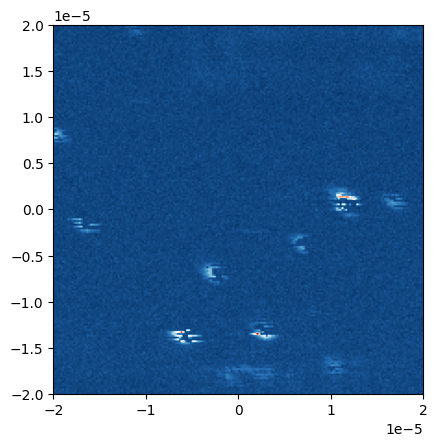

In [78]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

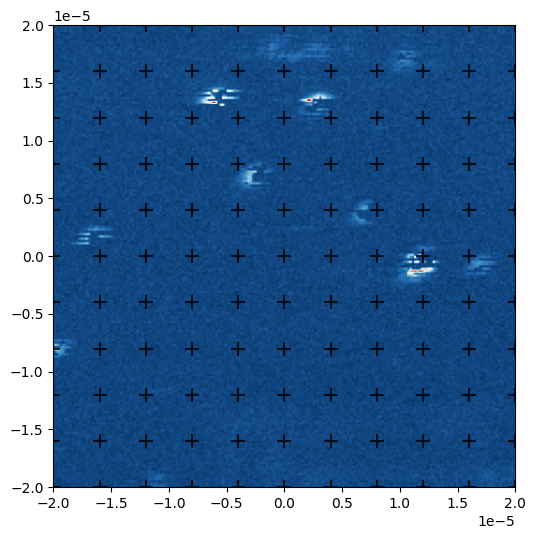

In [79]:
# make sure everything is a plain numpy array of floats
fig, ax = plt.subplots(figsize=(6,6))
pts_x   = np.asarray(X_grid).ravel().astype(float)
pts_y   = np.asarray(Y_grid).ravel().astype(float)
ax.imshow(imgdata,
          extent=extent,
          origin='lower',      # makes Y increase upward
          cmap='RdBu_r')
sc = ax.scatter(
    pts_x,
    pts_y,
    # c=cvals,          # now a real numpy array
    cmap='inferno',
    color='black',
    marker='+',
    s=100,
    alpha=0.8,
    edgecolors='none'
)

In [80]:
len(points_flat)

121

In [81]:
((10 * 4 * len(points_flat)) * 3) / 60 / 60 # hours ... !

4.033333333333333

In [82]:
def move_in_xy(xy_posi):
    x = xy_posi[0]
    y = xy_posi[1]
    z = poi_manager_logic.scanner_position[2]
    poi_manager_logic.move_scanner([x,y,z])
    return

In [83]:
points_flat[0]

array([-2.e-05, -2.e-05])

In [84]:
move_in_xy(points_flat[0])

In [ ]:
def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {
            'range': {ple_gui.scan_axis: in_range}
            ''
            }
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    # ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentzian")
    # time.sleep(0.2)
    # ple_gui._accumulated_data.mean(axis=0)
    # print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    # ple_gui.fit_result[1].params["center"].value
    return 1 #ple_gui.fit_result[1]
def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()

In [94]:
import os
import json

voltages = [5] #, 50, 80, 110]
# wavelength zero-point (in the same units as ws_wavemeter.get_current_wavelength())
w0 = 484.130 # THz

# directory where you want to save all of your PLE scans
out_folder = r"Z:\Vlad\heavyIV\197\2R\ref\inhomogeneous_ples"
os.makedirs(out_folder, exist_ok=True)

poi_tag = "def"
measurements = []

for idx, (x, y) in enumerate(points_flat[:3]):

    point_folder = os.path.join(out_folder, f"point_{idx}")
    os.makedirs(point_folder, exist_ok=True)

    move_in_xy((x, y))

    pt_record = {
        "point_index": idx,
        "x": float(x),
        "y": float(y),
        "scans": []
    }

    for V in voltages:
        
        set_laser_offset(V)

        current_wl = ws_wavemeter.get_current_wavelength()
        
        wavelength_GHz = (current_wl - w0) * 1e3

        fit_res = do_ple_scan(lines=10, frequency=100, resolution=1000) # 1000 sec 

        tag = f"point_{idx}_Voffset_{V}"
        save_ple(tag=tag,
                 poi_name=None,
                 folder_name=point_folder)

        filename = os.path.join(point_folder, f'{tag}')

        scan_record = {
            "voltage": float(V),
            "start_wavelength_GHz": float(wavelength_GHz),
            "filepath": filename
        }
        pt_record["scans"].append(scan_record)

    out_pt = {"measurements": measurements}
    with open(os.path.join(point_folder, "measurements.json"), "w") as jf:
        json.dump(out_pt, jf, indent=2)

    measurements.append(pt_record)
    
out = {"measurements": measurements}
with open(os.path.join(out_folder, "all_ple_measurements.json"), "w") as jf:
    json.dump(out, jf, indent=2)

print("Done! Saved JSON summary to all_ple_measurements.json")

Done! Saved JSON summary to all_ple_measurements.json


In [92]:
out = {"measurements": measurements}
with open(os.path.join(out_folder, "all_ple_measurements.json"), "w") as jf:
    json.dump(out, jf, indent=2)

print("Done! Saved JSON summary to all_ple_measurements.json")

Done! Saved JSON summary to all_ple_measurements.json


In [93]:
measurements

[{'point_index': 0, 'x': -2e-05, 'y': -2e-05, 'scans': [{'voltage': 5.0, 'start_wavelength_GHz': 16.02339674172981, 'filepath': 'Z:\\Vlad\\heavyIV\\197\\2R\\ref\\inhomogeneous_ples\\_tag'}]}, {'point_index': 1, 'x': -1.6000000000000003e-05, 'y': -2e-05, 'scans': [{'voltage': 5.0, 'start_wavelength_GHz': -21.315267987688458, 'filepath': 'Z:\\Vlad\\heavyIV\\197\\2R\\ref\\inhomogeneous_ples\\_tag'}]}, {'point_index': 2, 'x': -1.2000000000000004e-05, 'y': -2e-05, 'scans': [{'voltage': 5.0, 'start_wavelength_GHz': -21.390668999345053, 'filepath': 'Z:\\Vlad\\heavyIV\\197\\2R\\ref\\inhomogeneous_ples\\_tag'}]}]

In [86]:
ws_wavemeter.get_current_wavelength()

484.13330201705986

In [ ]:
fit_res = do_ple_scan(lines=10) # 400 sec